## Setup

In [14]:
import os
import re
import math
import json
import numpy as np
import pandas as pd
from pathlib import Path
from random import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
import torchinfo
import matplotlib.pyplot as plt
import seaborn as sns
import ast
%matplotlib inline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Helper functions

In [2]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    tokens = text.replace(",", " ").split()
    if not tokens:
        return None
    try:
        return np.asarray(tokens, dtype=np.float32)
    
    except ValueError:
        return None


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)

LABELS_JSON_PATH = Path("labels.json")
if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))
LABELS = 9
if LABELS == 9:
    # Map to 9 major classes.
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_9", {})
elif LABELS == 19:
    # Map to 19 classes (mostly 1-to-1 with raw labels).
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_19", {})
else:
    raise ValueError(f"Unsupported number of labels: {LABELS}")

def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur

POWER_BANDS = ['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma']

fft_feature_cols = [
    'fft_dominant_freq_hz',
    'fft_spectral_centroid_hz',
    'fft_spectral_entropy',
    'fft_power_delta',
    'fft_power_theta',
    'fft_power_alpha',
    'fft_power_beta',
    'fft_power_gamma',
]

# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

def summarize_vector(values, prefix):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {
            f"{prefix}_len": 0.0,
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_q05": np.nan,
            f"{prefix}_q95": np.nan,
            f"{prefix}_abs_mean": np.nan,
            f"{prefix}_clip_ratio": np.nan,
        }

    return {
        f"{prefix}_len": float(arr.size),
        f"{prefix}_mean": float(arr.mean()),
        f"{prefix}_std": float(arr.std()),
        f"{prefix}_min": float(arr.min()),
        f"{prefix}_max": float(arr.max()),
        f"{prefix}_median": float(np.median(arr)),
        f"{prefix}_q05": float(np.quantile(arr, 0.05)),
        f"{prefix}_q95": float(np.quantile(arr, 0.95)),
        f"{prefix}_abs_mean": float(np.mean(np.abs(arr))),
        f"{prefix}_clip_ratio": float(np.mean(np.abs(arr) >= 2047.0)),
    }

## Load the data

In [3]:
eeg_data = pd.read_csv("EEG/eeg_data_with_features.csv", converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
print("Shape after reloading from CSV:", eeg_data.shape)
random_index = np.random.choice(eeg_data.index)
raw_features = summarize_vector(eeg_data.loc[random_index, 'raw_values'], 'raw')
print(f"{len(POWER_BANDS)} power bands + {len(fft_feature_cols)} FFT features + {len(raw_features)} raw value summary features = {len(POWER_BANDS) + len(fft_feature_cols) + len(raw_features)} total features")

Shape after reloading from CSV: (9954, 31)
8 power bands + 8 FFT features + 10 raw value summary features = 26 total features


# IMAGINATION

In [4]:
def imaginator(random_sample, save_single=False, save_batch=False):
    r = random_sample[list(raw_features.keys())[1:-1]].values.astype(float)
    p = random_sample[POWER_BANDS].values.astype(float)
    f = random_sample[fft_feature_cols].values.astype(float)

    def normalize_matrix(mat):
        """
        Normalize matrix values adaptively:
        - signed range -> [-1, 1] (preserve sign)
        - nonnegative range -> [0, 1]
        """
        m = np.asarray(mat, dtype=np.float32)
        if not np.all(np.isfinite(m)):
            m = np.nan_to_num(m, nan=0.0, posinf=0.0, neginf=0.0)

        min_v = float(m.min())
        max_v = float(m.max())
        if np.isclose(max_v, min_v):
            return np.zeros_like(m, dtype=np.float32)

        # Signed data: scale symmetrically to preserve direction.
        if min_v < 0.0 and max_v > 0.0:
            denom = float(np.max(np.abs(m)))
            return (m / denom).astype(np.float32) if denom > 0 else np.zeros_like(m, dtype=np.float32)

        # Nonnegative (or nonpositive) data: min-max to [0, 1].
        return ((m - min_v) / (max_v - min_v)).astype(np.float32)

    r_outer_matrix = normalize_matrix(np.outer(r, r))
    r_dist_matrix = normalize_matrix(np.abs(r[:, None] - r[None, :]))

    p_outer_matrix = normalize_matrix(np.outer(p, p))
    p_dist_matrix = normalize_matrix(np.abs(p[:, None] - p[None, :]))

    f_outer_matrix = normalize_matrix(np.outer(f, f))
    f_dist_matrix = normalize_matrix(np.abs(f[:, None] - f[None, :]))

    rf_outer_matrix = normalize_matrix(np.outer(r, f))
    rp_outer_matrix = normalize_matrix(np.outer(r, p))
    fp_outer_matrix = normalize_matrix(np.outer(f, p))

    rf_dist_matrix = normalize_matrix(np.abs(r[:, None] - f[None, :]))
    rp_dist_matrix = normalize_matrix(np.abs(r[:, None] - p[None, :]))
    fp_dist_matrix = normalize_matrix(np.abs(f[:, None] - p[None, :]))

    fig, axs = plt.subplots(2, 6, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)

    # outers
    im0 = axs[0, 0].imshow(r_outer_matrix, cmap='viridis')
    axs[0, 0].set_title('Raw x Raw')
    axs[0, 0].set_ylabel('Outer Product')
    im0 = axs[0, 1].imshow(p_outer_matrix, cmap='viridis')
    axs[0, 1].set_title('Power x Power')
    im0 = axs[0, 2].imshow(f_outer_matrix, cmap='viridis')
    axs[0, 2].set_title('FFT x FFT')
    im0 = axs[0, 3].imshow(rf_outer_matrix, cmap='viridis')
    axs[0, 3].set_title('Raw x FFT')
    im0 = axs[0, 4].imshow(rp_outer_matrix, cmap='viridis')
    axs[0, 4].set_title('Raw x Power')
    im0 = axs[0, 5].imshow(fp_outer_matrix, cmap='viridis')
    axs[0, 5].set_title('Power x FFT')

    # distances
    im1 = axs[1, 0].imshow(r_dist_matrix, cmap='inferno')
    axs[1, 0].set_title('Raw <> Raw')
    axs[1, 0].set_ylabel('Distance')
    im1 = axs[1, 1].imshow(p_dist_matrix, cmap='inferno')
    axs[1, 1].set_title('Power <> Power')
    im1 = axs[1, 2].imshow(f_dist_matrix, cmap='inferno')
    axs[1, 2].set_title('FFT <> FFT')
    im1 = axs[1, 3].imshow(rf_dist_matrix, cmap='inferno')
    axs[1, 3].set_title('Raw <> FFT')
    im1 = axs[1, 4].imshow(rp_dist_matrix, cmap='inferno')
    axs[1, 4].set_title('Raw <> Power')
    im1 = axs[1, 5].imshow(fp_dist_matrix, cmap='inferno')
    axs[1, 5].set_title('Power <> FFT')

    fig.colorbar(im0, ax=axs[0, :], location='right', fraction=0.02, pad=0.02, shrink=0.6)
    fig.colorbar(im1, ax=axs[1, :], location='right', fraction=0.02, pad=0.02, shrink=0.6)
    
    if save_batch:
        os.makedirs('imgs', exist_ok=True)
        fig.savefig(f'imgs/imaginator_batch.png', dpi=300)

    plt.show()

Class label: thinkOfItems


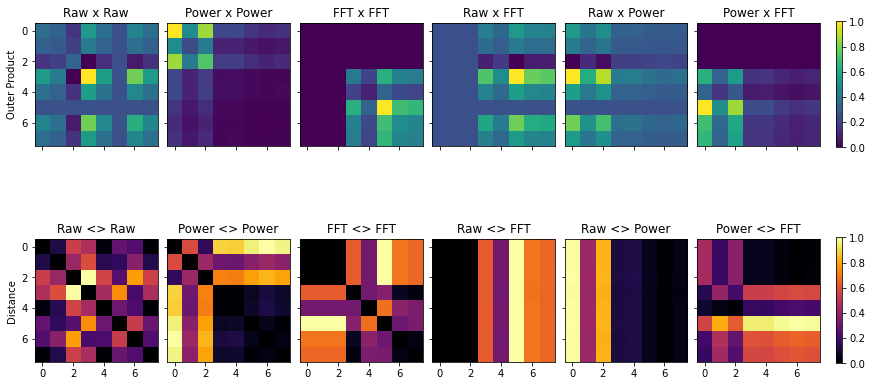

Class label: video


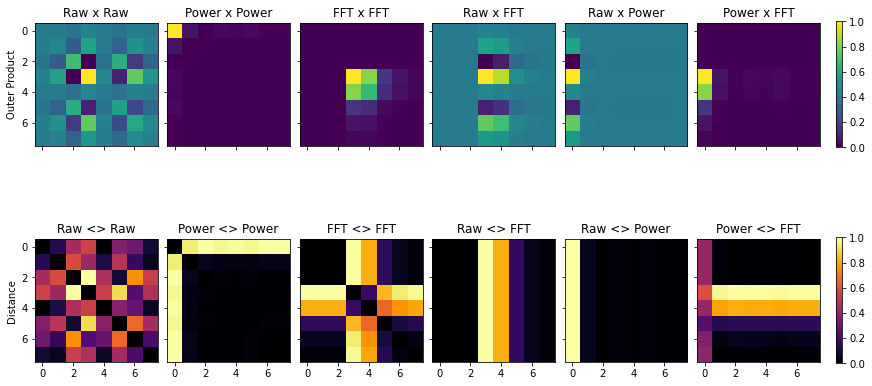

In [5]:
# Sample one valid row safely
random_state = int(random() * 10000)
random_sample1 = eeg_data.sample(n=1, random_state=random_state).iloc[0]
print(f"Class label: {random_sample1['label']}")
imaginator(random_sample1)

random_sample2 = eeg_data.sample(n=1, random_state=random_state+1).iloc[0]
print(f"Class label: {random_sample2['label']}")
imaginator(random_sample2)

# CNN on 12-Matrix Image Tensors

Each sample is encoded as a **(12 × 8 × 8)** image:

- channels 0–1: Raw-feature outer product & pairwise absolute difference
- channels 2–3: Power-band outer product & pairwise absolute difference
- channels 4–5: FFT-feature outer product & pairwise absolute difference
- channels 6–11: Raw-Power-FFT outer product and pairwise absolute difference, respectively!

Split is **subject-leakage-free** (GroupShuffleSplit, 80 / 20).  
Normalization is **per-channel**, computed on the training set only.


Image tensor shape: (9954, 12, 8, 8)
Train: (8032, 12, 8, 8)  (24 subjects)
Val:   (1922, 12, 8, 8)  (6 subjects)


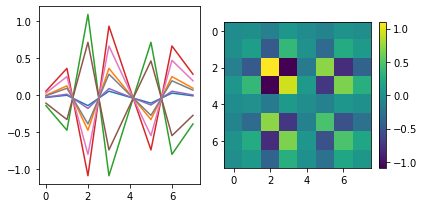

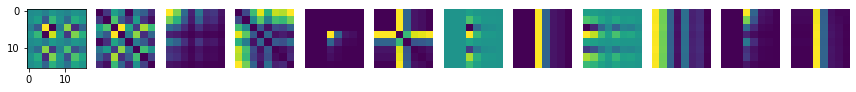


SCALE=16  |  batch_size=64
Dataset RAM (8×8, both splits): 30.6 MB
Peak RAM per batch (approx):    0.8 MB
Loader — train: 126 batches, val: 31 batches


In [31]:
# -- 1. Build (N, 12, 8, 8) matrix tensors --
raw_cols = list(raw_features.keys())[1:-1]  # 8 stat cols

R_feat = eeg_data[raw_cols].values.astype(np.float32)
P_feat = eeg_data[POWER_BANDS].values.astype(np.float32)
F_feat = eeg_data[fft_feature_cols].values.astype(np.float32)

R_outer = np.einsum('ni,nj->nij', R_feat, R_feat)
R_dist = np.abs(R_feat[:, :, None] - R_feat[:, None, :])
P_outer = np.einsum('ni,nj->nij', P_feat, P_feat)
P_dist = np.abs(P_feat[:, :, None] - P_feat[:, None, :])
F_outer = np.einsum('ni,nj->nij', F_feat, F_feat)
F_dist = np.abs(F_feat[:, :, None] - F_feat[:, None, :])

RF_outer = np.einsum('ni,nj->nij', R_feat, F_feat)
RF_dist = np.abs(R_feat[:, :, None] - F_feat[:, None, :])
RP_outer = np.einsum('ni,nj->nij', R_feat, P_feat)
RP_dist = np.abs(R_feat[:, :, None] - P_feat[:, None, :])
PF_outer = np.einsum('ni,nj->nij', P_feat, F_feat)
PF_dist = np.abs(P_feat[:, :, None] - F_feat[:, None, :])

X_img = np.stack([R_outer, R_dist, P_outer, P_dist, F_outer, F_dist, RF_outer, RF_dist, RP_outer, RP_dist, PF_outer, PF_dist], axis=1)
print(f"Image tensor shape: {X_img.shape}")

# -- 2. Encode labels + GroupShuffleSplit (80% train / 20% val) --
if 'le' not in globals():
    le = LabelEncoder()
    le.fit(eeg_data['label'].values)

y_img = le.transform(eeg_data['label'].values)
y_img = np.asarray(y_img)
groups_img = eeg_data['id'].values
groups_img = np.asarray(groups_img)

gss_img = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx_img, va_idx_img = next(gss_img.split(X_img, y_img, groups=groups_img))

X_tr_img, X_va_img = X_img[tr_idx_img], X_img[va_idx_img]
y_tr_img, y_va_img = y_img[tr_idx_img], y_img[va_idx_img]
groups_tr_img, groups_va_img = groups_img[tr_idx_img], groups_img[va_idx_img]

n_tr_subj = len(np.unique(groups_tr_img))
n_va_subj = len(np.unique(groups_va_img))
print(f"Train: {X_tr_img.shape}  ({n_tr_subj} subjects)")
print(f"Val:   {X_va_img.shape}  ({n_va_subj} subjects)")

# -- 3. Per-channel normalization (train statistics only) --
ch_mean = X_tr_img.mean(axis=(0, 2, 3), keepdims=True)
ch_std = X_tr_img.std(axis=(0, 2, 3), keepdims=True) + 1e-8

X_tr_img = (X_tr_img - ch_mean) / ch_std
X_va_img = (X_va_img - ch_mean) / ch_std

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].plot(X_tr_img[0, 0])
im1 = axs[1].imshow(X_tr_img[0, 0])
fig.colorbar(im1, ax=axs[-1], location='right', 
            fraction=0.045, 
#             # pad=0.02,
#             shrink=0.75
            )
plt.tight_layout()
plt.show()

# -- SCALE: target spatial resolution ----------------------------------------
# The dataset is stored at the native 8×8 resolution.  Upscaling to (SCALE×SCALE)
# is done lazily per sample inside __getitem__ so only one batch at a time is
# ever materialized at the large resolution.
#
# Memory comparison for N=10 000 samples, 12 channels, float32:
#   Eager (old)  SCALE=256 → 10 000 × 12 × 256 × 256 × 4 B  ≈ 31.5 GB  ×2 copies = OOM
#   Lazy (new)   any SCALE → 10 000 × 12 ×   8 ×   8 × 4 B  ≈ 30 MB stored;
#   peak per batch ≈ batch_size × 12 × SCALE² × 4 B

SCALE = 16
batch_size_cnn = 64

# Visualization only — upscale one sample to verify appearance
_vis = F.interpolate(
    torch.tensor(X_tr_img[0:1], dtype=torch.float32),
    size=(SCALE, SCALE), mode='nearest'
)
fig, axs = plt.subplots(1, 12, figsize=(12, 4), sharex=True, sharey=True)
for i in range(12):
    axs[i].imshow(_vis[0, i].numpy())
    if i != 0:
        axs[i].axis('off')
# plt.suptitle(f'Sample channels — upscaled to {SCALE}×{SCALE} (display only)', y=0.65)
plt.tight_layout()
plt.show()
del _vis

# -- 4. Dataset + DataLoaders -------------------------------------------------
# Stores 8×8 arrays in RAM; upscales each sample on-the-fly in __getitem__.
class EEGMatrixDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, scale: int = 8):
        # Keep as a numpy float32 array — no second tensor copy of the full data.
        self.X = X.astype(np.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.scale = scale

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).unsqueeze(0)          # (1, C, 8, 8)
        if self.scale != self.X.shape[-1]:
            x = F.interpolate(x, size=(self.scale, self.scale), mode='nearest')
        return x.squeeze(0), self.y[idx]                         # (C, SCALE, SCALE)

train_loader_cnn = DataLoader(
    EEGMatrixDataset(X_tr_img, y_tr_img, scale=SCALE),
    batch_size=batch_size_cnn,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    pin_memory=False,
)
val_loader_cnn = DataLoader(
    EEGMatrixDataset(X_va_img, y_va_img, scale=SCALE),
    batch_size=batch_size_cnn,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=False,
)

# -- 5. Class weights (inverse frequency on training split) --
num_classes = len(np.unique(y_img))
counts_cnn = np.bincount(y_tr_img, minlength=num_classes).astype(float)
cw_cnn = torch.tensor(1.0 / np.maximum(counts_cnn, 1), dtype=torch.float32)
cw_cnn = (cw_cnn / cw_cnn.sum() * num_classes).to(device)

_bytes_per_batch = batch_size_cnn * 12 * SCALE * SCALE * 4
print(f"\nSCALE={SCALE}  |  batch_size={batch_size_cnn}")
print(f"Dataset RAM (8×8, both splits): {(X_tr_img.nbytes + X_va_img.nbytes) / 1e6:.1f} MB")
print(f"Peak RAM per batch (approx):    {_bytes_per_batch / 1e6:.1f} MB")
print(f"Loader — train: {len(train_loader_cnn)} batches, val: {len(val_loader_cnn)} batches")

In [40]:
class EEGMatrixCNN(nn.Module):
    def __init__(self, in_channels=12, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 4, kernel_size=7, padding=1), nn.BatchNorm2d(4), nn.ReLU(),
            nn.Conv2d(          4, 4, kernel_size=3, padding=1), nn.BatchNorm2d(4), nn.ReLU(),
            nn.Conv2d(          4, 4, kernel_size=3, padding=1), nn.BatchNorm2d(4), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                               
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4, 2), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(2, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn_model = EEGMatrixCNN(in_channels=12, num_classes=num_classes).to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)
cnn_criterion = nn.CrossEntropyLoss(weight=cw_cnn)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5
)

# If a previous best checkpoint exists, load it. Otherwise keep default PyTorch init.
# cnn_checkpoint_path = Path("outputs/processed/cnn_single_best.pt")
# if cnn_checkpoint_path.exists():
#     checkpoint = torch.load(cnn_checkpoint_path, map_location=device)
#     if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
#         cnn_model.load_state_dict(checkpoint["model_state_dict"])
#     else:
#         cnn_model.load_state_dict(checkpoint)
#     print(f"Loaded previous best CNN weights from {cnn_checkpoint_path}")
# else:
#     print("No previous CNN checkpoint found; using default PyTorch initialization.")

print(torchinfo.summary(cnn_model, input_size=(1, 12, 8, 8)))
print(f"Trainable parameters: {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}")

Layer (type:depth-idx)                   Output Shape              Param #
EEGMatrixCNN                             [1, 9]                    --
├─Sequential: 1-1                        [1, 4, 1, 1]              --
│    └─Conv2d: 2-1                       [1, 4, 4, 4]              2,356
│    └─BatchNorm2d: 2-2                  [1, 4, 4, 4]              8
│    └─ReLU: 2-3                         [1, 4, 4, 4]              --
│    └─Conv2d: 2-4                       [1, 4, 4, 4]              148
│    └─BatchNorm2d: 2-5                  [1, 4, 4, 4]              8
│    └─ReLU: 2-6                         [1, 4, 4, 4]              --
│    └─Conv2d: 2-7                       [1, 4, 4, 4]              148
│    └─BatchNorm2d: 2-8                  [1, 4, 4, 4]              8
│    └─ReLU: 2-9                         [1, 4, 4, 4]              --
│    └─AdaptiveAvgPool2d: 2-10           [1, 4, 1, 1]              --
├─Sequential: 1-2                        [1, 9]                    --
│    └─Flatte

Epoch   1/100 | TLoss: 2.2648  TF1: 0.0432 | VLoss: 2.2382  VF1: 0.0433 | LR: 3.00e-04  <- best
Epoch   5/100 | TLoss: 2.2277  TF1: 0.0438 | VLoss: 2.2148  VF1: 0.0433 | LR: 3.00e-04
Epoch  10/100 | TLoss: 2.2120  TF1: 0.0562 | VLoss: 2.2032  VF1: 0.0433 | LR: 1.50e-04
Epoch  15/100 | TLoss: 2.2049  TF1: 0.0580 | VLoss: 2.2001  VF1: 0.0433 | LR: 7.50e-05
Epoch  17/100 | TLoss: 2.2044  TF1: 0.0561 | VLoss: 2.1989  VF1: 0.0438 | LR: 7.50e-05  <- best
Epoch  18/100 | TLoss: 2.2053  TF1: 0.0583 | VLoss: 2.1973  VF1: 0.0441 | LR: 7.50e-05  <- best
Epoch  20/100 | TLoss: 2.2013  TF1: 0.0586 | VLoss: 2.1986  VF1: 0.0451 | LR: 7.50e-05  <- best
Epoch  23/100 | TLoss: 2.2018  TF1: 0.0569 | VLoss: 2.1964  VF1: 0.0498 | LR: 7.50e-05  <- best
Epoch  24/100 | TLoss: 2.2020  TF1: 0.0589 | VLoss: 2.1972  VF1: 0.0501 | LR: 7.50e-05  <- best
Epoch  25/100 | TLoss: 2.1971  TF1: 0.0591 | VLoss: 2.1975  VF1: 0.0597 | LR: 7.50e-05  <- best
Epoch  30/100 | TLoss: 2.1993  TF1: 0.0577 | VLoss: 2.1966  VF1: 0.

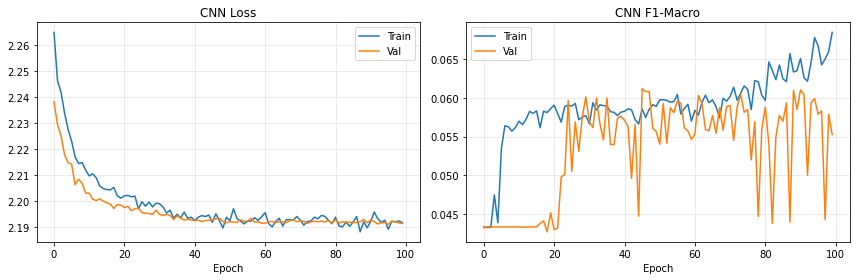

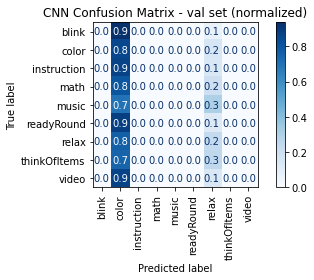

In [41]:
cnn_num_epochs       = 100
cnn_best_f1          = -1.0
cnn_best_epoch       = 0
cnn_best_weights     = None
cnn_patience         = 20
cnn_patience_counter = 0
cnn_min_delta        = 1e-4
cnn_history          = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

if 'cnn_checkpoint_path' not in globals():
    cnn_checkpoint_path = Path("outputs/processed/cnn_single_best.pt")

for epoch in range(1, cnn_num_epochs + 1):
    # Train
    cnn_model.train()
    tr_loss, tr_preds, tr_targets = 0.0, [], []
    for xb, yb in train_loader_cnn:
        xb, yb = xb.to(device), yb.to(device)
        cnn_optimizer.zero_grad()
        logits = cnn_model(xb)
        loss   = cnn_criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        cnn_optimizer.step()
        tr_loss += loss.item() * len(yb)
        tr_preds.extend(logits.argmax(1).detach().cpu().numpy())
        tr_targets.extend(yb.cpu().numpy())

    tr_loss /= len(y_tr_img)
    tr_f1 = f1_score(tr_targets, tr_preds, average='macro', zero_division=0)

    # Validate
    cnn_model.eval()
    va_loss, va_preds, va_targets = 0.0, [], []
    with torch.no_grad():
        for xb, yb in val_loader_cnn:
            xb, yb = xb.to(device), yb.to(device)
            logits  = cnn_model(xb)
            va_loss += cnn_criterion(logits, yb).item() * len(yb)
            va_preds.extend(logits.argmax(1).cpu().numpy())
            va_targets.extend(yb.cpu().numpy())

    va_loss /= len(y_va_img)
    va_f1 = f1_score(va_targets, va_preds, average='macro', zero_division=0)

    cnn_scheduler.step(va_f1)
    cnn_history['train_loss'].append(tr_loss)
    cnn_history['val_loss'].append(va_loss)
    cnn_history['train_f1'].append(tr_f1)
    cnn_history['val_f1'].append(va_f1)

    improved = va_f1 > cnn_best_f1 + cnn_min_delta
    if improved:
        cnn_best_f1, cnn_best_epoch = va_f1, epoch
        cnn_best_weights = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}
        torch.save(
            {
                'epoch': epoch,
                'val_f1_macro': float(va_f1),
                'model_state_dict': cnn_best_weights,
            },
            cnn_checkpoint_path,
        )
        cnn_patience_counter = 0
    else:
        cnn_patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = '  <- best' if improved else ''
        print(
            f"Epoch {epoch:3d}/{cnn_num_epochs} | "
            f"TLoss: {tr_loss:.4f}  TF1: {tr_f1:.4f} | "
            f"VLoss: {va_loss:.4f}  VF1: {va_f1:.4f} | "
            f"LR: {cnn_optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

    # if cnn_patience_counter >= cnn_patience:
    #     print(
    #         f"\nEarly stop at epoch {epoch} "
    #         f"(best: epoch {cnn_best_epoch}, val F1: {cnn_best_f1:.4f})"
    #     )
    #     break

if cnn_best_weights is None:
    cnn_best_weights = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}

cnn_model.load_state_dict({k: v.to(device) for k, v in cnn_best_weights.items()})
print(f"\nRestored best checkpoint - Val F1-macro: {cnn_best_f1:.4f}")
print(f"Saved/loaded checkpoint path: {cnn_checkpoint_path}")

# Final evaluation
cnn_model.eval()
cnn_final_preds, cnn_final_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader_cnn:
        logits = cnn_model(xb.to(device))
        cnn_final_preds.extend(logits.argmax(1).cpu().numpy())
        cnn_final_targets.extend(yb.numpy())

print("\nClassification Report (CNN - 12-matrix images):")
print(classification_report(
    cnn_final_targets, cnn_final_preds,
    target_names=le.classes_, zero_division=0))

# Training curves
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(cnn_history['train_loss'], label='Train')
axs[0].plot(cnn_history['val_loss'], label='Val')
axs[0].set_title('CNN Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(cnn_history['train_f1'], label='Train')
axs[1].plot(cnn_history['val_f1'], label='Val')
axs[1].set_title('CNN F1-Macro')
axs[1].set_xlabel('Epoch')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrix (compatible with older scikit-learn versions)
cnn_cm = confusion_matrix(cnn_final_targets, cnn_final_preds, normalize='true')
cnn_disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=le.classes_)
cnn_disp.plot(cmap='Blues', xticks_rotation=90, values_format='.1f')
plt.title('CNN Confusion Matrix - val set (normalized)')
plt.tight_layout()
plt.show()

In [29]:
class _BranchCNN(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 4, kernel_size=7, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.features(x).flatten(1) 


class EEGDualBranchCNN(nn.Module):
    def __init__(self, branch_in_channels=6, num_classes=9, dropout=0.4):
        super().__init__()
        # Identical branch architectures
        self.outer_branch = _BranchCNN(in_channels=branch_in_channels)
        self.dist_branch = _BranchCNN(in_channels=branch_in_channels)

        self.classifier = nn.Sequential(
            nn.Linear(4 * 2, 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4, num_classes),
        )

    def forward(self, x):
        if x.ndim != 4:
            raise ValueError(f"Expected 4D input (B, C, H, W), got shape {tuple(x.shape)}")
        if x.shape[1] % 2 != 0:
            raise ValueError(f"Expected an even number of channels, got {x.shape[1]}")

        # Split by channel parity: even indices are outer matrices, odd are distance matrices.
        x_outer = x[:, 0::2, :, :]
        x_dist = x[:, 1::2, :, :]

        z_outer = self.outer_branch(x_outer)
        z_dist = self.dist_branch(x_dist)
        z = torch.cat([z_outer, z_dist], dim=1)
        return self.classifier(z)


# Instantiate dual-branch model for your (12, 8, 8) representation.
dual_cnn_model = EEGDualBranchCNN(branch_in_channels=6, num_classes=num_classes).to(device)

# If a previous best checkpoint exists, load it. Otherwise keep default PyTorch init.
# dual_checkpoint_path = Path("outputs/processed/cnn_dual_best.pt")
# if dual_checkpoint_path.exists():
#     checkpoint = torch.load(dual_checkpoint_path, map_location=device)
#     if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
#         dual_cnn_model.load_state_dict(checkpoint["model_state_dict"])
#     else:
#         dual_cnn_model.load_state_dict(checkpoint)
#     print(f"Loaded previous best dual-branch CNN weights from {dual_checkpoint_path}")
# else:
#     print("No previous dual-branch checkpoint found; using default PyTorch initialization.")

print(torchinfo.summary(dual_cnn_model, input_size=(1, 12, SCALE, SCALE)))
print(f"Trainable parameters: {sum(p.numel() for p in dual_cnn_model.parameters() if p.requires_grad):,}")

Layer (type:depth-idx)                   Output Shape              Param #
EEGDualBranchCNN                         [1, 9]                    --
├─_BranchCNN: 1-1                        [1, 4]                    --
│    └─Sequential: 2-1                   [1, 4, 1, 1]              --
│    │    └─Conv2d: 3-1                  [1, 4, 60, 60]            1,180
│    │    └─BatchNorm2d: 3-2             [1, 4, 60, 60]            8
│    │    └─ReLU: 3-3                    [1, 4, 60, 60]            --
│    │    └─Conv2d: 3-4                  [1, 4, 60, 60]            148
│    │    └─BatchNorm2d: 3-5             [1, 4, 60, 60]            8
│    │    └─ReLU: 3-6                    [1, 4, 60, 60]            --
│    │    └─AdaptiveAvgPool2d: 3-7       [1, 4, 1, 1]              --
├─_BranchCNN: 1-2                        [1, 4]                    --
│    └─Sequential: 2-2                   [1, 4, 1, 1]              --
│    │    └─Conv2d: 3-8                  [1, 4, 60, 60]            1,180
│    │    

Epoch   1/100 | TLoss: 2.2473  TF1: 0.0331 | VLoss: 2.2167  VF1: 0.0428 | LR: 3.00e-04  <- best
Epoch   5/100 | TLoss: 2.1825  TF1: 0.0356 | VLoss: 2.1827  VF1: 0.0374 | LR: 3.00e-04
Epoch  10/100 | TLoss: 2.1755  TF1: 0.0434 | VLoss: 2.1766  VF1: 0.0341 | LR: 1.50e-04
Epoch  15/100 | TLoss: 2.1599  TF1: 0.0556 | VLoss: 2.1697  VF1: 0.0325 | LR: 7.50e-05
Epoch  20/100 | TLoss: 2.1609  TF1: 0.0597 | VLoss: 2.1685  VF1: 0.0316 | LR: 3.75e-05
Epoch  25/100 | TLoss: 2.1646  TF1: 0.0644 | VLoss: 2.1660  VF1: 0.0322 | LR: 1.87e-05
Epoch  30/100 | TLoss: 2.1547  TF1: 0.0687 | VLoss: 2.1619  VF1: 0.0329 | LR: 1.87e-05
Epoch  35/100 | TLoss: 2.1584  TF1: 0.0702 | VLoss: 2.1668  VF1: 0.0319 | LR: 1.00e-05
Epoch  40/100 | TLoss: 2.1608  TF1: 0.0701 | VLoss: 2.1664  VF1: 0.0318 | LR: 1.00e-05
Epoch  45/100 | TLoss: 2.1586  TF1: 0.0721 | VLoss: 2.1618  VF1: 0.0320 | LR: 1.00e-05
Epoch  50/100 | TLoss: 2.1626  TF1: 0.0734 | VLoss: 2.1633  VF1: 0.0324 | LR: 1.00e-05
Epoch  51/100 | TLoss: 2.1586  TF1

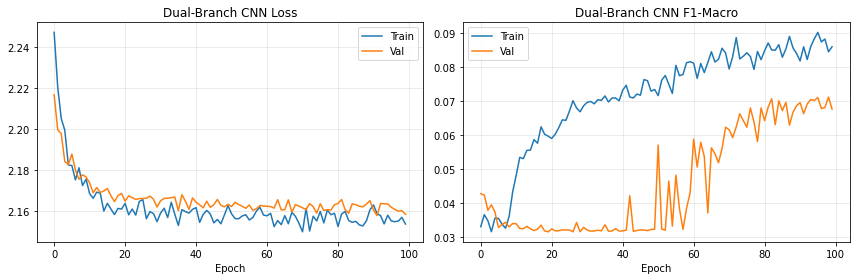

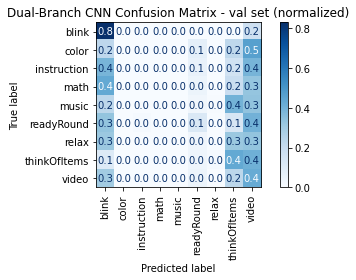

In [30]:
# Training + validation loop for dual-branch CNN (same style as previous loop)
dual_optimizer = optim.Adam(dual_cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)
dual_criterion = nn.CrossEntropyLoss(weight=cw_cnn)
dual_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    dual_optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5
)

dual_num_epochs = 100
dual_best_f1 = -1.0
dual_best_epoch = 0
dual_best_weights = None
dual_patience = 20
dual_patience_counter = 0
dual_min_delta = 1e-4
dual_history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': [],
}

if 'dual_checkpoint_path' not in globals():
    dual_checkpoint_path = Path("outputs/processed/cnn_dual_best.pt")

for epoch in range(1, dual_num_epochs + 1):
    # Train
    dual_cnn_model.train()
    tr_loss, tr_preds, tr_targets = 0.0, [], []

    for xb, yb in train_loader_cnn:
        xb, yb = xb.to(device), yb.to(device)
        dual_optimizer.zero_grad()
        logits = dual_cnn_model(xb)
        loss = dual_criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(dual_cnn_model.parameters(), 1.0)
        dual_optimizer.step()

        tr_loss += loss.item() * len(yb)
        tr_preds.extend(logits.argmax(1).detach().cpu().numpy())
        tr_targets.extend(yb.detach().cpu().numpy())

    tr_loss /= len(y_tr_img)
    tr_f1 = f1_score(tr_targets, tr_preds, average='macro', zero_division=0)

    # Validate
    dual_cnn_model.eval()
    va_loss, va_preds, va_targets = 0.0, [], []

    with torch.no_grad():
        for xb, yb in val_loader_cnn:
            xb, yb = xb.to(device), yb.to(device)
            logits = dual_cnn_model(xb)
            loss = dual_criterion(logits, yb)
            va_loss += loss.item() * len(yb)
            va_preds.extend(logits.argmax(1).cpu().numpy())
            va_targets.extend(yb.cpu().numpy())

    va_loss /= len(y_va_img)
    va_f1 = f1_score(va_targets, va_preds, average='macro', zero_division=0)

    dual_scheduler.step(va_f1)
    dual_history['train_loss'].append(tr_loss)
    dual_history['val_loss'].append(va_loss)
    dual_history['train_f1'].append(tr_f1)
    dual_history['val_f1'].append(va_f1)

    improved = va_f1 > (dual_best_f1 + dual_min_delta)
    if improved:
        dual_best_f1 = va_f1
        dual_best_epoch = epoch
        dual_best_weights = {k: v.detach().cpu().clone() for k, v in dual_cnn_model.state_dict().items()}
        torch.save(
            {
                'epoch': epoch,
                'val_f1_macro': float(va_f1),
                'model_state_dict': dual_best_weights,
            },
            dual_checkpoint_path,
        )
        dual_patience_counter = 0
    else:
        dual_patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = '  <- best' if improved else ''
        print(
            f"Epoch {epoch:3d}/{dual_num_epochs} | "
            f"TLoss: {tr_loss:.4f}  TF1: {tr_f1:.4f} | "
            f"VLoss: {va_loss:.4f}  VF1: {va_f1:.4f} | "
            f"LR: {dual_optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

    # if dual_patience_counter >= dual_patience:
    #     print(
    #         f"\nEarly stop at epoch {epoch} "
    #         f"(best: epoch {dual_best_epoch}, val F1: {dual_best_f1:.4f})"
    #     )
    #     break

if dual_best_weights is None:
    dual_best_weights = {k: v.detach().cpu().clone() for k, v in dual_cnn_model.state_dict().items()}

dual_cnn_model.load_state_dict({k: v.to(device) for k, v in dual_best_weights.items()})
print(f"\nRestored best checkpoint - Val F1-macro: {dual_best_f1:.4f}")
print(f"Saved/loaded checkpoint path: {dual_checkpoint_path}")

# Final evaluation
dual_cnn_model.eval()
dual_final_preds, dual_final_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader_cnn:
        logits = dual_cnn_model(xb.to(device))
        dual_final_preds.extend(logits.argmax(1).cpu().numpy())
        dual_final_targets.extend(yb.numpy())

print("\nClassification Report (Dual-branch CNN):")
print(
    classification_report(
        dual_final_targets,
        dual_final_preds,
        target_names=le.classes_,
        zero_division=0,
    )
)

# Training curves
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(dual_history['train_loss'], label='Train')
axs[0].plot(dual_history['val_loss'], label='Val')
axs[0].set_title('Dual-Branch CNN Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(dual_history['train_f1'], label='Train')
axs[1].plot(dual_history['val_f1'], label='Val')
axs[1].set_title('Dual-Branch CNN F1-Macro')
axs[1].set_xlabel('Epoch')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrix (compatible with older scikit-learn versions)
dual_cm = confusion_matrix(dual_final_targets, dual_final_preds, normalize='true')
dual_disp = ConfusionMatrixDisplay(confusion_matrix=dual_cm, display_labels=le.classes_)
dual_disp.plot(cmap='Blues', xticks_rotation=90, values_format='.1f')
plt.title('Dual-Branch CNN Confusion Matrix - val set (normalized)')
plt.tight_layout()
plt.show()